# Régression Logistique — Prédiction de la Gravité des Accidents Routiers (2024)

**Objectif :** Prédire la gravité d'un accident routier parmi trois classes :
- `0` — Blessé léger
- `1` — Blessé hospitalisé  
- `2` — Tué

à partir de 12 variables contextuelles (luminosité, météo, type de route, vitesse, etc.)  
en utilisant une **Régression Logistique Multinomiale**.

**Données utilisées :** `X_oh_encoding.csv` (encodage One-Hot, 81 colonnes — adapté aux modèles linéaires)  
**Auteur :** Issam

---

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import time
import warnings

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    roc_curve,
    auc,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# ── Constantes globales ───────────────────────────────────────────────────────
LABELS_MAP  = {0: "Blessé léger", 1: "Blessé hospitalisé", 2: "Tué"}
CLASS_NAMES = [LABELS_MAP[i] for i in range(3)]
PALETTE     = ["#4C9BE8", "#F5A623", "#E84C4C"]   # bleu, orange, rouge

print("Imports OK.")

Imports OK.


## 2. Chargement des Données

In [2]:
# ── Chargement ────────────────────────────────────────────────────────────────
# X_oh_encoding : encodage One-Hot → indispensable pour les modèles linéaires
# X_lab_encoded : encodage ordinal → utilisé uniquement pour les visualisations EDA
X     = pd.read_csv("donnees/clean/X_oh_encoding.csv")
y     = pd.read_csv("donnees/clean/y_gravite.csv").squeeze()
X_lab = pd.read_csv("donnees/clean/X_lab_encoded.csv")

with open("donnees/clean/label_encoding_mappings.json", encoding="utf-8") as f:
    mappings = json.load(f)

print(f"X (OHE)  — {X.shape[0]:,} lignes × {X.shape[1]} colonnes")
print(f"X (lab)  — {X_lab.shape[0]:,} lignes × {X_lab.shape[1]} colonnes")
print(f"y        — {y.shape[0]:,} lignes")

print("\n── Valeurs manquantes dans X (OHE) :")
nan_counts = X.isnull().sum()
nan_cols   = nan_counts[nan_counts > 0]
for col, n in nan_cols.items():
    print(f"  {col:<20}  {n:>5} valeurs ({n/len(X)*100:.1f}%)")

print("\n── Distribution de la variable cible :")
for cls, lbl in LABELS_MAP.items():
    n = (y == cls).sum()
    print(f"  {cls} — {lbl:<22}  {n:>6} ({n/len(y)*100:.1f}%)")

X (OHE)  — 54,401 lignes × 81 colonnes
X (lab)  — 54,401 lignes × 12 colonnes
y        — 54,401 lignes

── Valeurs manquantes dans X (OHE) :
  Vitesse_num             760 valeurs (1.4%)
  Voies_num              2264 valeurs (4.2%)

── Distribution de la variable cible :
  0 — Blessé léger             34743 (63.9%)
  1 — Blessé hospitalisé       16432 (30.2%)
  2 — Tué                       3226 (5.9%)


## 3. Analyse Exploratoire des Données (EDA)

### 3.1 Répartition de la variable cible

Avant toute modélisation, il est essentiel de visualiser la distribution des classes cibles.
Un fort déséquilibre peut biaiser un modèle vers les classes majoritaires.

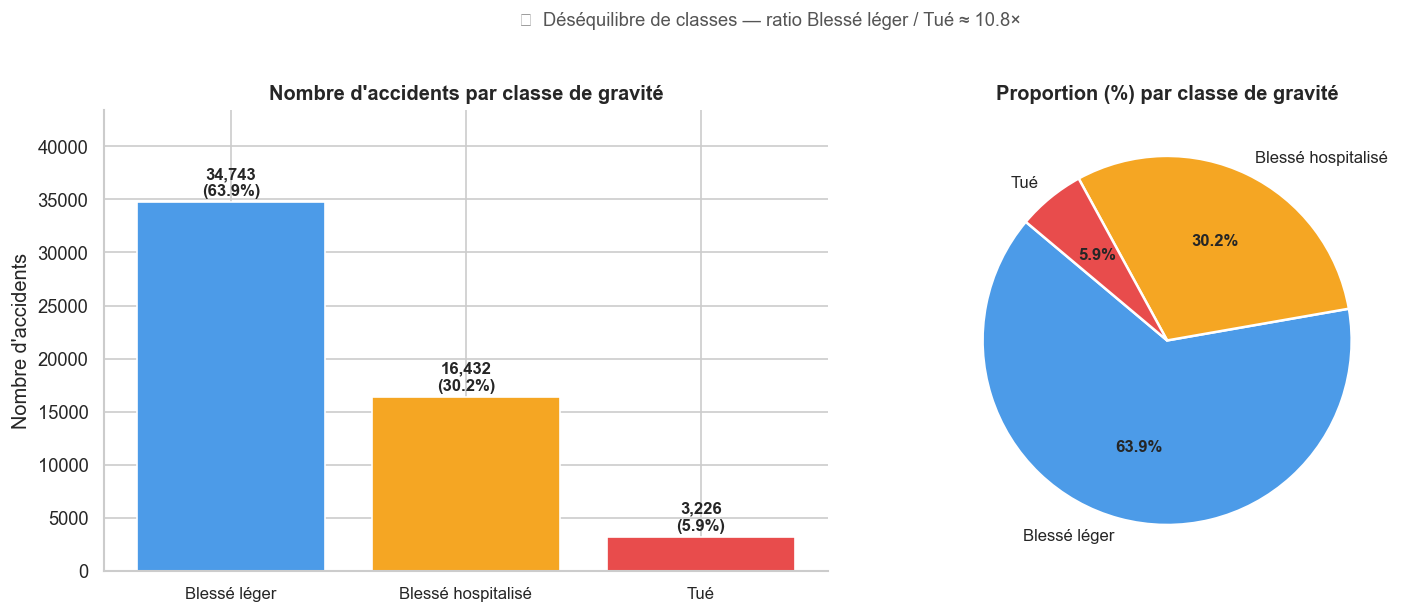

Ratio max/min : 10.8×
→ class_weight='balanced' sera appliqué dans le modèle pour corriger ce déséquilibre.


In [3]:
counts = y.value_counts().sort_index()
labels_display = [LABELS_MAP[i] for i in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Bar chart ─────────────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(labels_display, counts.values, color=PALETTE,
              edgecolor="white", linewidth=1)
for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f"{val:,}\n({val/len(y)*100:.1f}%)",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )
ax.set_title("Nombre d'accidents par classe de gravité", fontsize=12, fontweight="bold")
ax.set_ylabel("Nombre d'accidents")
ax.set_ylim(0, counts.max() * 1.25)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", labelsize=10)

# ── Pie chart ─────────────────────────────────────────────────────────────────
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=labels_display,
    colors=PALETTE,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
    textprops={"fontsize": 10},
)
for at in autotexts:
    at.set_fontweight("bold")
ax2.set_title("Proportion (%) par classe de gravité", fontsize=12, fontweight="bold")

fig.suptitle(
    "⚠  Déséquilibre de classes — ratio Blessé léger / Tué ≈ 10.8×",
    fontsize=11, color="#555555", y=1.02
)
plt.tight_layout()
plt.show()

ratio = counts[0] / counts[2]
print(f"Ratio max/min : {ratio:.1f}×")
print("→ class_weight='balanced' sera appliqué dans le modèle pour corriger ce déséquilibre.")

### 3.2 Variables contextuelles et gravité

Pour chaque variable catégorielle, on visualise la **proportion de chaque classe de gravité**  
dans chaque modalité, afin d'identifier les facteurs les plus discriminants.

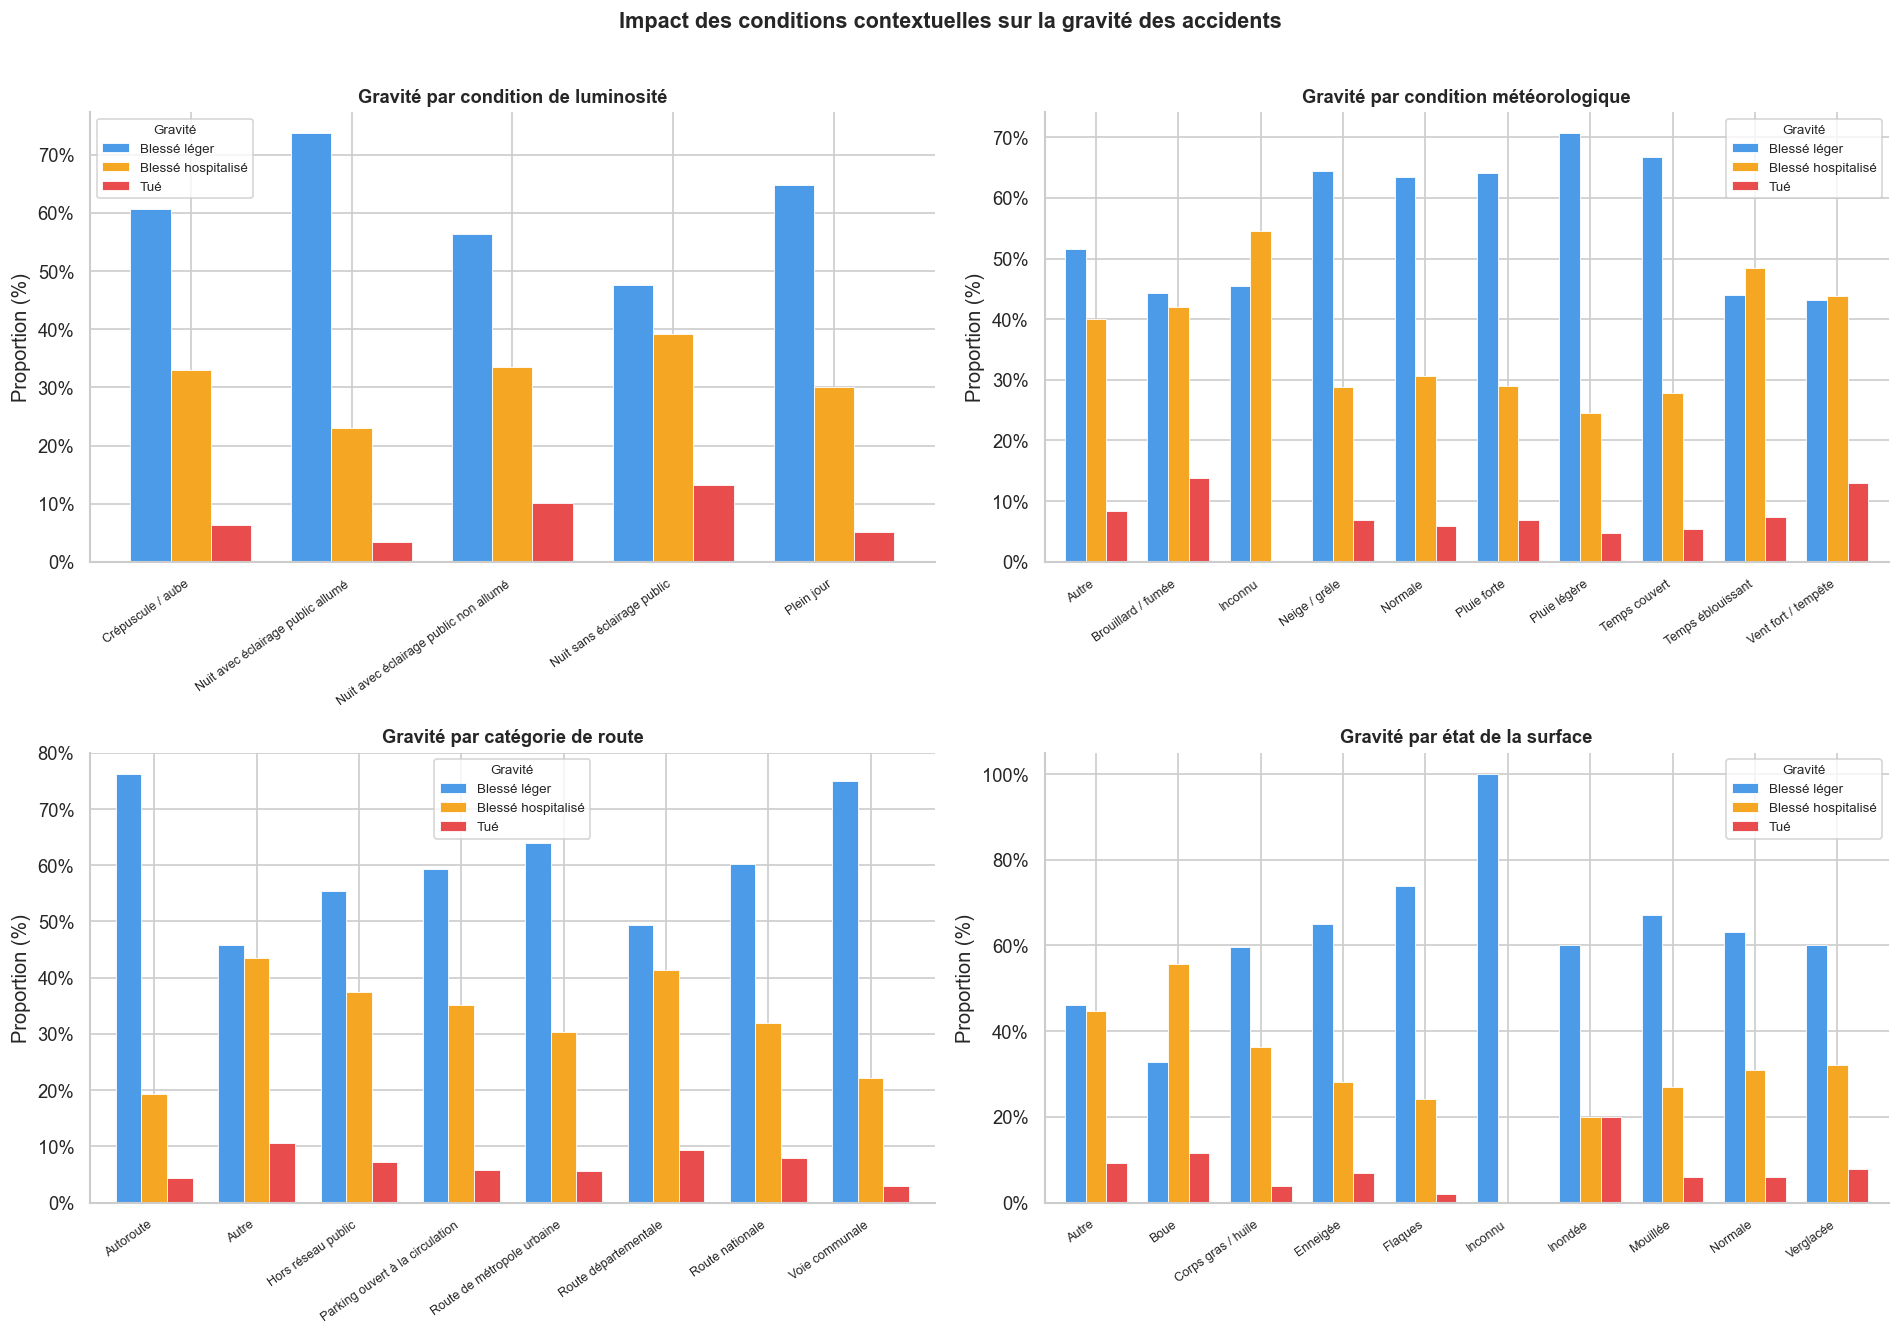

In [4]:
def plot_feature_vs_target(col, map_key, title, ax):
    """Bar chart groupé : proportion de gravité par modalité d'une variable."""
    df_tmp = pd.DataFrame({"feat": X_lab[col].astype(float), "grav": y})

    if map_key in mappings:
        rev = {float(k): v for k, v in mappings[map_key].items()}
        df_tmp["feat"] = df_tmp["feat"].map(rev).fillna("Inconnu")

    ct = pd.crosstab(df_tmp["feat"], df_tmp["grav"], normalize="index") * 100
    ct.columns = [LABELS_MAP[c] for c in ct.columns]
    ct.plot(kind="bar", ax=ax, color=PALETTE, edgecolor="white",
            linewidth=0.5, width=0.75)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Proportion (%)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=7.5)
    ax.legend(title="Gravité", fontsize=8, title_fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))


fig, axes = plt.subplots(2, 2, figsize=(16, 11))

plot_feature_vs_target(
    "Luminosité", "Luminosité",
    "Gravité par condition de luminosité", axes[0, 0]
)
plot_feature_vs_target(
    "Météo (conditions atmos.)", "Météo (conditions atmos.)",
    "Gravité par condition météorologique", axes[0, 1]
)
plot_feature_vs_target(
    "Catégorie de route", "Catégorie de route",
    "Gravité par catégorie de route", axes[1, 0]
)
plot_feature_vs_target(
    "État de la surface", "État de la surface",
    "Gravité par état de la surface", axes[1, 1]
)

fig.suptitle(
    "Impact des conditions contextuelles sur la gravité des accidents",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

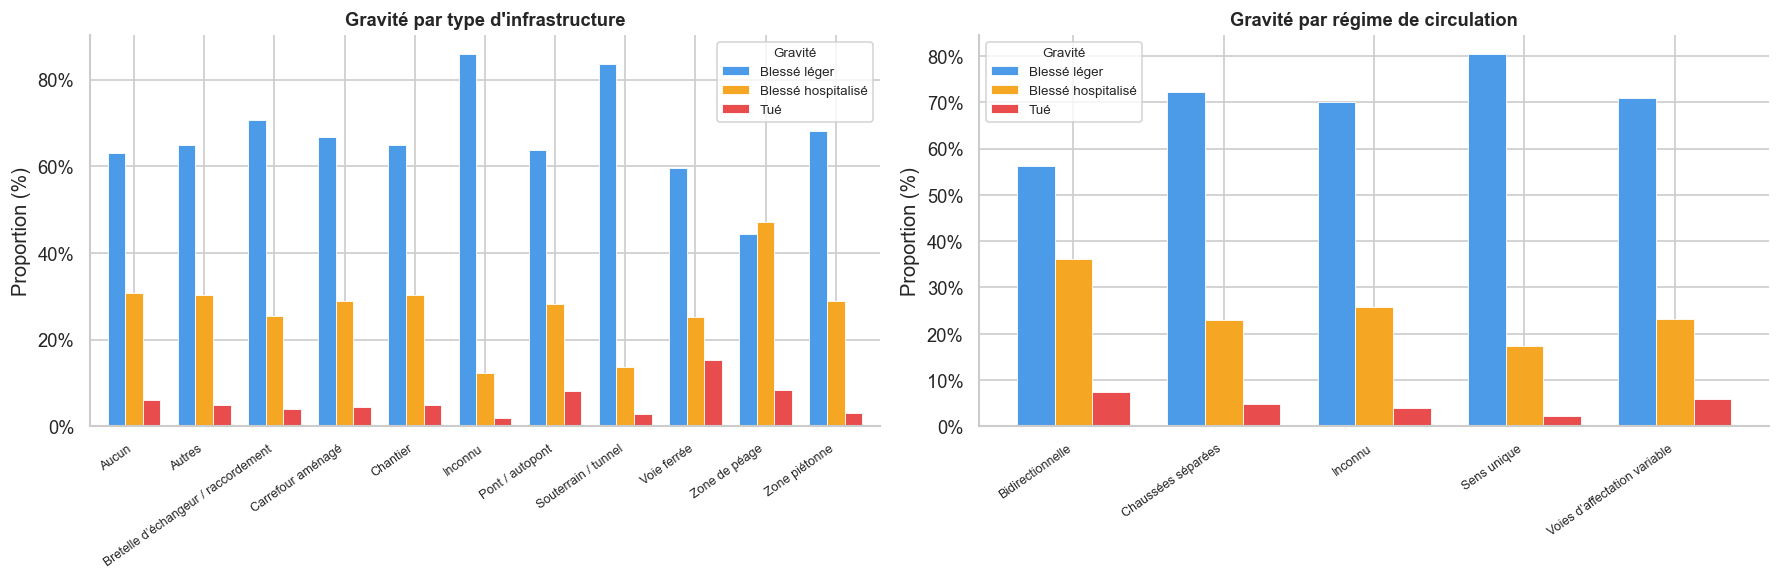

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_feature_vs_target(
    "Infrastructure", "Infrastructure",
    "Gravité par type d'infrastructure", axes[0]
)
plot_feature_vs_target(
    "Régime de circulation", "Régime de circulation",
    "Gravité par régime de circulation", axes[1]
)

plt.tight_layout()
plt.show()

### 3.3 Distribution de la vitesse par classe de gravité

La vitesse maximale autorisée est l'une des variables numériques du dataset.  
On s'attend à ce que les accidents mortels surviennent plus souvent à des vitesses élevées.

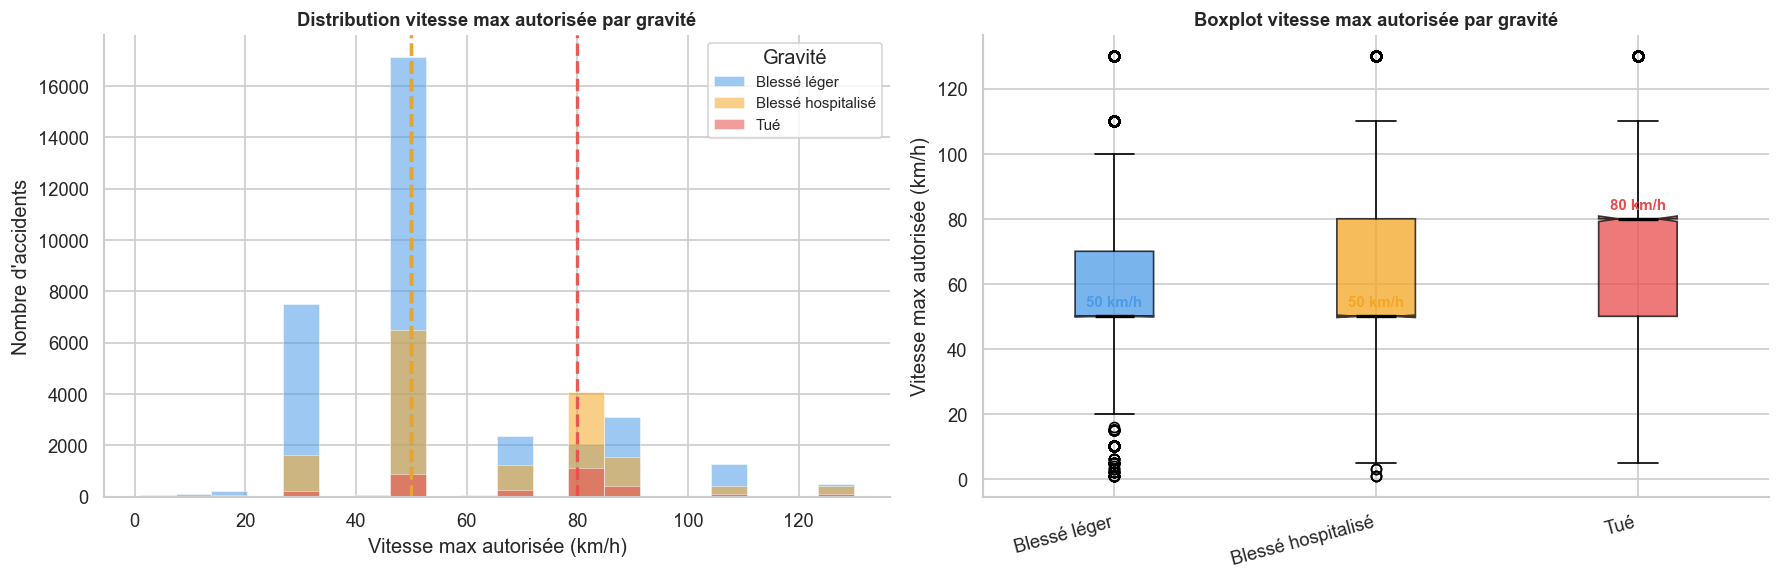

Médianes de vitesse par classe :
  Blessé léger           → 50 km/h
  Blessé hospitalisé     → 50 km/h
  Tué                    → 80 km/h


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Histogramme superposé ─────────────────────────────────────────────────────
ax = axes[0]
valid_speeds = X_lab["Vitesse_num"].dropna()
bin_edges = np.histogram_bin_edges(valid_speeds, bins=20)

for i, (cls, label) in enumerate(LABELS_MAP.items()):
    speeds = X_lab.loc[y == cls, "Vitesse_num"].dropna()
    ax.hist(speeds, bins=bin_edges, alpha=0.55, color=PALETTE[i],
            label=label, edgecolor="white", linewidth=0.5)
    med = speeds.median()
    ax.axvline(med, color=PALETTE[i], linestyle="--", linewidth=2, alpha=0.9)

ax.set_title("Distribution vitesse max autorisée par gravité",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Vitesse max autorisée (km/h)")
ax.set_ylabel("Nombre d'accidents")
ax.legend(title="Gravité", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# ── Boxplot ───────────────────────────────────────────────────────────────────
ax2 = axes[1]
data_box  = [X_lab.loc[y == cls, "Vitesse_num"].dropna().values
             for cls in LABELS_MAP]
bp = ax2.boxplot(data_box, patch_artist=True, notch=True,
                 medianprops={"color": "black", "linewidth": 2})
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.set_xticklabels(CLASS_NAMES, rotation=15, ha="right")
ax2.set_title("Boxplot vitesse max autorisée par gravité",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("Vitesse max autorisée (km/h)")
ax2.spines[["top", "right"]].set_visible(False)

# Médiane annotée
for i, (cls, label) in enumerate(LABELS_MAP.items()):
    med = X_lab.loc[y == cls, "Vitesse_num"].median()
    ax2.text(i + 1, med + 3, f"{med:.0f} km/h",
             ha="center", fontsize=9, color=PALETTE[i], fontweight="bold")

plt.tight_layout()
plt.show()

print("Médianes de vitesse par classe :")
for cls, lbl in LABELS_MAP.items():
    med = X_lab.loc[y == cls, "Vitesse_num"].median()
    print(f"  {lbl:<22} → {med:.0f} km/h")

### 3.4 Distribution du nombre de voies par classe

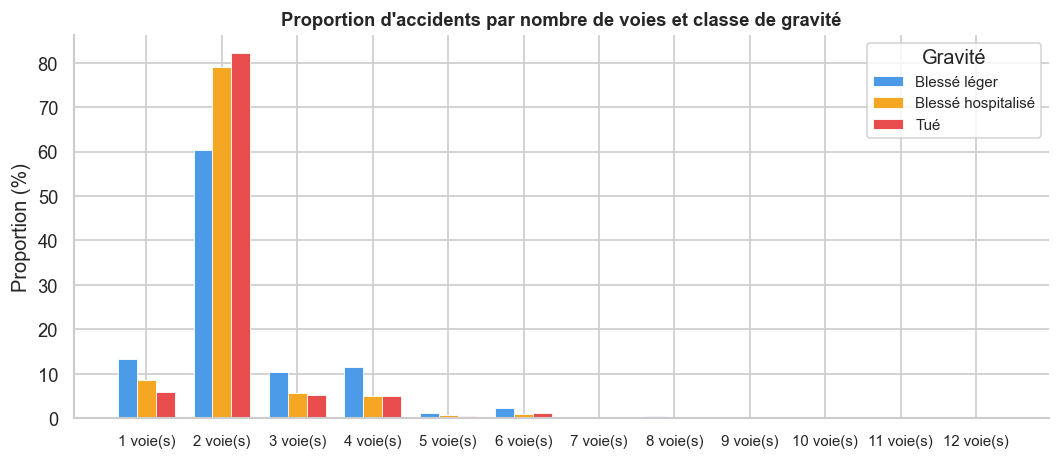

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))

voies_valides = X_lab["Voies_num"].dropna()
voies_categories = sorted(voies_valides.unique())

x_pos    = np.arange(len(voies_categories))
bar_w    = 0.25

for i, (cls, label) in enumerate(LABELS_MAP.items()):
    counts_v = [
        (X_lab.loc[y == cls, "Voies_num"] == v).sum()
        for v in voies_categories
    ]
    total = sum(counts_v)
    proportions = [c / total * 100 for c in counts_v]
    ax.bar(x_pos + i * bar_w, proportions, bar_w, label=label,
           color=PALETTE[i], edgecolor="white", linewidth=0.5)

ax.set_xticks(x_pos + bar_w)
ax.set_xticklabels([f"{int(v)} voie(s)" for v in voies_categories], fontsize=9)
ax.set_title("Proportion d'accidents par nombre de voies et classe de gravité",
             fontsize=11, fontweight="bold")
ax.set_ylabel("Proportion (%)")
ax.legend(title="Gravité", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 3.5 Valeurs manquantes

Seules deux colonnes numériques contiennent des NaN.  
L'imputation sera réalisée **après** le split train/test pour éviter toute fuite de données.

    Colonne  NaN (n)  NaN (%)          Stratégie
Vitesse_num      760 1.397033 Médiane (Pipeline)
  Voies_num     2264 4.161688 Médiane (Pipeline)


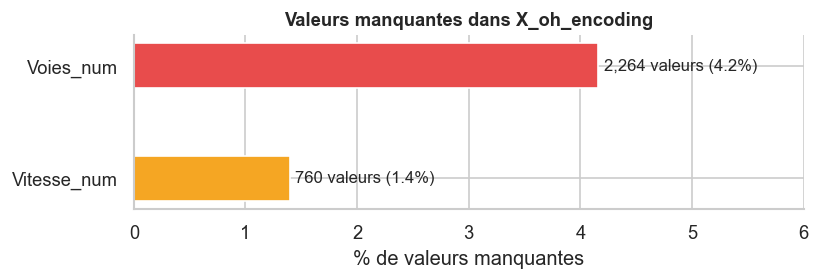


→ Les NaN sont uniquement dans les colonnes numériques.
  Imputation par la médiane appliquée APRÈS le split (via Pipeline).
  Les 11 lignes de Météo manquante sont encodées en vecteur zéro dans l'OHE.


In [8]:
nan_info = pd.DataFrame({
    "Colonne":    ["Vitesse_num", "Voies_num"],
    "NaN (n)":    [760, 2264],
    "NaN (%)": [760/len(X)*100, 2264/len(X)*100],
    "Stratégie":  ["Médiane (Pipeline)", "Médiane (Pipeline)"],
})
print(nan_info.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 2.5))
colors_bar = ["#F5A623", "#E84C4C"]
bars = ax.barh(nan_info["Colonne"], nan_info["NaN (%)"],
               color=colors_bar, edgecolor="white", height=0.4)
for bar, val, n in zip(bars, nan_info["NaN (%)"], nan_info["NaN (n)"]):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"{n:,} valeurs ({val:.1f}%)",
            va="center", fontsize=10)
ax.set_xlim(0, 6)
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("Valeurs manquantes dans X_oh_encoding", fontsize=11, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("\n→ Les NaN sont uniquement dans les colonnes numériques.")
print("  Imputation par la médiane appliquée APRÈS le split (via Pipeline).")
print("  Les 11 lignes de Météo manquante sont encodées en vecteur zéro dans l'OHE.")

## 4. Séparation Apprentissage / Test

Split 80% / 20% avec **stratification** sur `y` pour conserver les proportions de classes  
dans chaque jeu — essentiel avec un dataset déséquilibré.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Séparation 80 % / 20 % avec stratify=y")
print(f"  Train : {len(X_train):>6,} lignes")
print(f"  Test  : {len(X_test):>6,} lignes")

print("\nProportions des classes (doivent être stables) :")
print(f"  {'Classe':<22}  {'Train':>7}  {'Test':>7}  {'Global':>7}")
print("  " + "-" * 45)
for cls, lbl in LABELS_MAP.items():
    p_tr = (y_train == cls).mean() * 100
    p_te = (y_test  == cls).mean() * 100
    p_gl = (y       == cls).mean() * 100
    print(f"  {lbl:<22}  {p_tr:>6.1f}%  {p_te:>6.1f}%  {p_gl:>6.1f}%")

Séparation 80 % / 20 % avec stratify=y
  Train : 43,520 lignes
  Test  : 10,881 lignes

Proportions des classes (doivent être stables) :
  Classe                    Train     Test   Global
  ---------------------------------------------
  Blessé léger              63.9%    63.9%    63.9%
  Blessé hospitalisé        30.2%    30.2%    30.2%
  Tué                        5.9%     5.9%     5.9%


## 5. Pipeline — Imputation → Normalisation → Régression Logistique

> **Pourquoi la normalisation est indispensable pour la Régression Logistique ?**  
> La RL optimise un problème de maximisation de vraisemblance avec des **combinaisons linéaires**  
> des features. `Vitesse_num` (0–130 km/h) et une colonne OHE binaire (0 ou 1) sont sur des  
> échelles très différentes : sans normalisation, la convergence est lente et les coefficients  
> ne sont pas comparables entre eux.  
> `StandardScaler` centre et réduit chaque feature → convergence rapide et coefficients interprétables.
>
> **Pourquoi le solver L-BFGS ?**  
> Algorithme quasi-Newton efficace pour les datasets de taille moyenne (~54k lignes, 81 colonnes).  
> Supporte la régularisation L1, L2 et Elastic-Net.
>
> **Pourquoi `class_weight='balanced'` ?**  
> Ratio Blessé léger / Tué ≈ 10.8×. Sans correction, le modèle prédit quasi-exclusivement  
> la classe majoritaire et ignore les accidents mortels — inacceptable dans ce contexte de  
> sécurité publique.

In [10]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("clf",     LogisticRegression(
        class_weight="balanced",
        solver="lbfgs",
        max_iter=1000,
        random_state=42,
        C=1.0,
    )),
])

print("Pipeline construit :")
for name, step in pipeline.steps:
    print(f"  ▸ {name:<10} → {step}")

Pipeline construit :
  ▸ imputer    → SimpleImputer(strategy='median')
  ▸ scaler     → StandardScaler()
  ▸ clf        → LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


## 6. Entraînement du Modèle

In [11]:
t0 = time.time()
pipeline.fit(X_train, y_train)
elapsed = time.time() - t0

clf = pipeline["clf"]
print(f"Modèle entraîné en {elapsed:.1f} s")
print(f"Nombre d'itérations jusqu'à convergence : {clf.n_iter_[0]}")
print(f"Paramètre de régularisation C           : {clf.C}")
print(f"class_weight                            : {clf.class_weight}")

Modèle entraîné en 35.0 s
Nombre d'itérations jusqu'à convergence : 35
Paramètre de régularisation C           : 1.0
class_weight                            : balanced


## 7. Évaluation du Modèle

### 7.1 Rapport de classification

Avec un dataset déséquilibré, **l'accuracy globale est trompeuse**.  
On s'appuie sur la **précision**, le **rappel** et le **F1-score** par classe.

In [12]:
y_pred = pipeline.predict(X_test)

print("=" * 62)
print("RAPPORT DE CLASSIFICATION — Régression Logistique")
print("=" * 62)
print(classification_report(
    y_test, y_pred,
    target_names=CLASS_NAMES,
    digits=3
))

acc = (y_pred == y_test).mean()
print(f"Accuracy globale : {acc:.3f}")

RAPPORT DE CLASSIFICATION — Régression Logistique
                    precision    recall  f1-score   support

      Blessé léger      0.825     0.687     0.750      6949
Blessé hospitalisé      0.430     0.327     0.371      3287
               Tué      0.151     0.609     0.242       645

          accuracy                          0.574     10881
         macro avg      0.469     0.541     0.455     10881
      weighted avg      0.666     0.574     0.606     10881

Accuracy globale : 0.574


### 7.2 Matrice de confusion

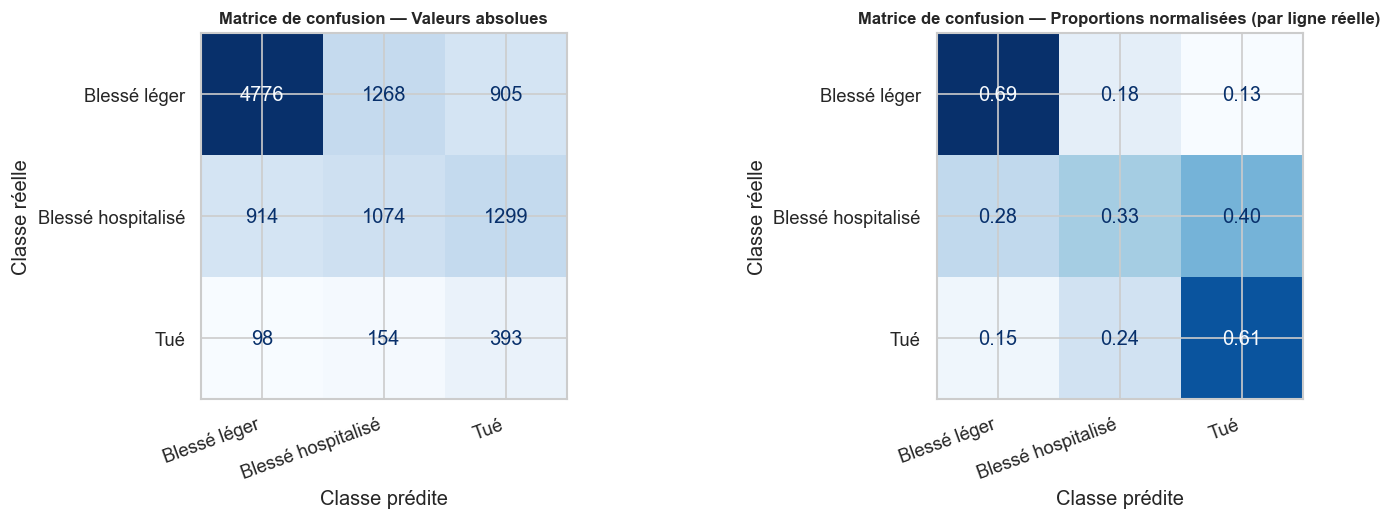

Lecture : chaque ligne = classe réelle, chaque colonne = classe prédite.
La diagonale représente les prédictions correctes.


In [13]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, matrix, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Valeurs absolues", "Proportions normalisées (par ligne réelle)"],
    ["d", ".2f"]
):
    disp = ConfusionMatrixDisplay(matrix, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format=fmt)
    ax.set_title(f"Matrice de confusion — {title}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Classe prédite")
    ax.set_ylabel("Classe réelle")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.show()

print("Lecture : chaque ligne = classe réelle, chaque colonne = classe prédite.")
print("La diagonale représente les prédictions correctes.")

### 7.3 Métriques par classe — Précision, Rappel, F1-score

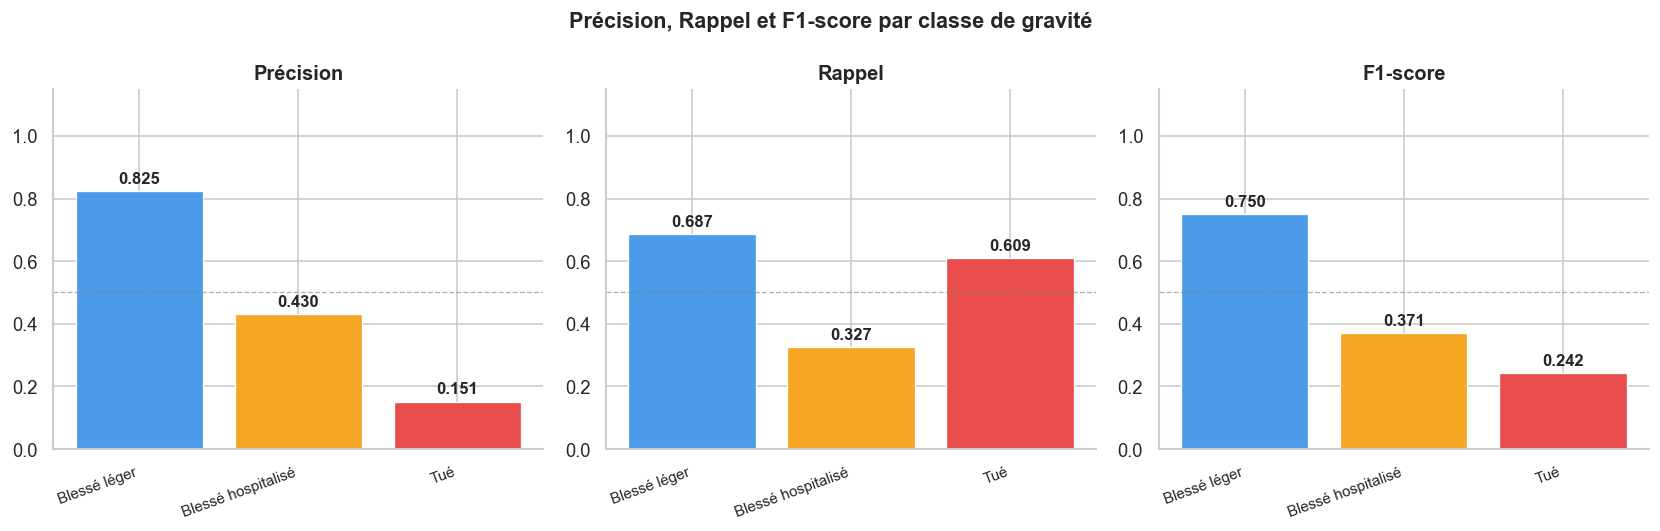

Résumé métriques :
  Classe                   Précision    Rappel        F1
  ----------------------------------------------------
  Blessé léger                 0.825     0.687     0.750
  Blessé hospitalisé           0.430     0.327     0.371
  Tué                          0.151     0.609     0.242


In [14]:
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=[0, 1, 2]
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
metric_data = [
    ("Précision",  prec),
    ("Rappel",     rec),
    ("F1-score",   f1),
]

for ax, (metric_name, values) in zip(axes, metric_data):
    bars = ax.bar(CLASS_NAMES, values, color=PALETTE,
                  edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold"
        )
    ax.set_title(metric_name, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.set_xticklabels(CLASS_NAMES, rotation=20, ha="right", fontsize=9)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6,
               label="seuil 0.5")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Précision, Rappel et F1-score par classe de gravité",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

print("Résumé métriques :")
print(f"  {'Classe':<22}  {'Précision':>10}  {'Rappel':>8}  {'F1':>8}")
print("  " + "-" * 52)
for cls, lbl in LABELS_MAP.items():
    print(f"  {lbl:<22}  {prec[cls]:>10.3f}  {rec[cls]:>8.3f}  {f1[cls]:>8.3f}")

### 7.4 Courbes ROC (One-vs-Rest)

La Régression Logistique produit des **probabilités de classe** directement.  
La courbe ROC et l'AUC mesurent la capacité de **discrimination** du modèle pour chaque classe,  
indépendamment du seuil de décision — particulièrement utile avec des classes déséquilibrées.

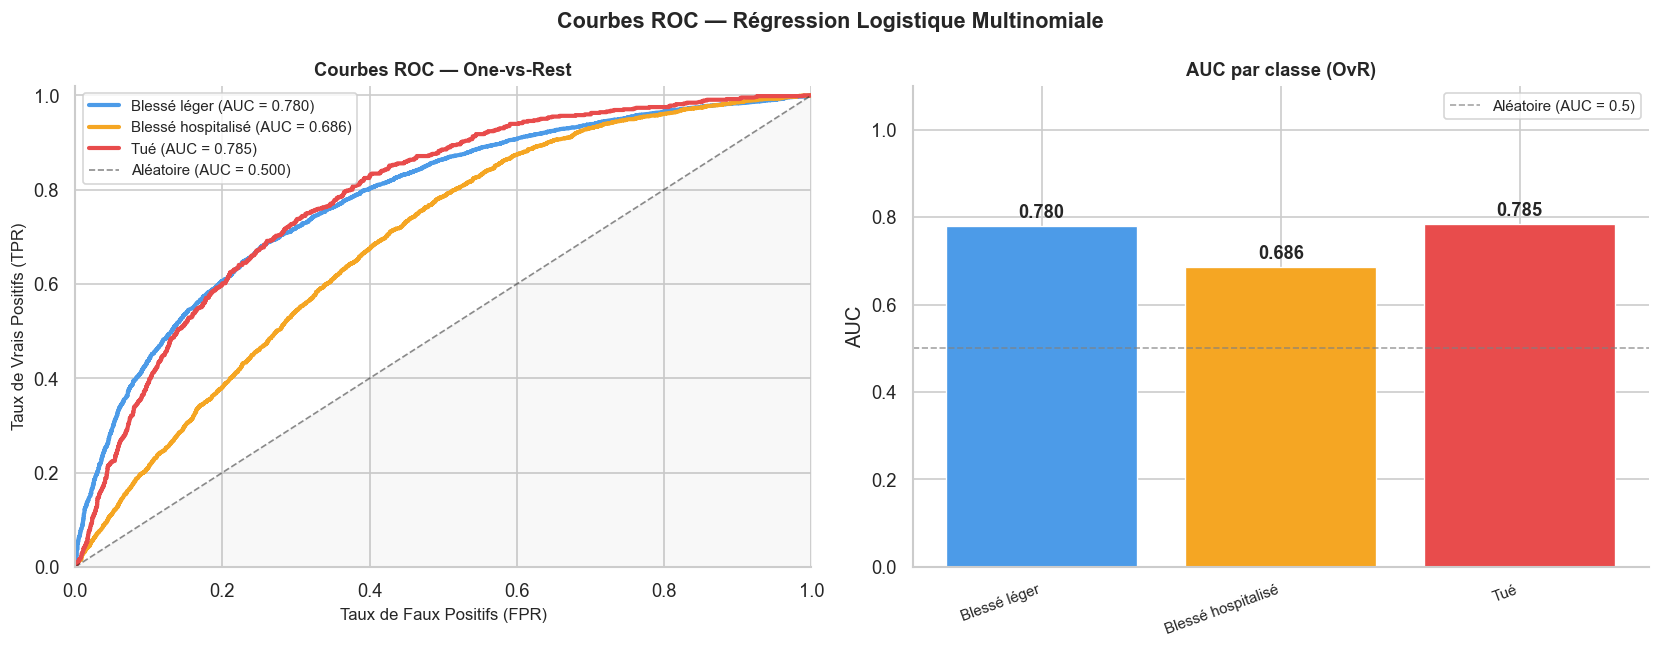

AUC par classe :
  Blessé léger           → AUC = 0.780
  Blessé hospitalisé     → AUC = 0.686
  Tué                    → AUC = 0.785


In [15]:
y_proba    = pipeline.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Courbes ROC séparées ──────────────────────────────────────────────────────
ax = axes[0]
for i, (cls, label) in enumerate(LABELS_MAP.items()):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=PALETTE[i], linewidth=2.5,
            label=f"{label} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5,
        label="Aléatoire (AUC = 0.500)")
ax.fill_between([0, 1], [0, 1], alpha=0.05, color="gray")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel("Taux de Faux Positifs (FPR)", fontsize=10)
ax.set_ylabel("Taux de Vrais Positifs (TPR)", fontsize=10)
ax.set_title("Courbes ROC — One-vs-Rest", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# ── AUC par classe (bar chart) ────────────────────────────────────────────────
ax2 = axes[1]
aucs = []
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    aucs.append(auc(fpr, tpr))

bars = ax2.bar(CLASS_NAMES, aucs, color=PALETTE, edgecolor="white", linewidth=0.8)
ax2.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.7,
            label="Aléatoire (AUC = 0.5)")
for bar, val in zip(bars, aucs):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f"{val:.3f}",
             ha="center", va="bottom", fontsize=11, fontweight="bold")
ax2.set_ylim(0, 1.1)
ax2.set_title("AUC par classe (OvR)", fontsize=11, fontweight="bold")
ax2.set_ylabel("AUC")
ax2.set_xticklabels(CLASS_NAMES, rotation=20, ha="right", fontsize=9)
ax2.legend(fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Courbes ROC — Régression Logistique Multinomiale",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

print("AUC par classe :")
for cls, lbl in LABELS_MAP.items():
    print(f"  {lbl:<22} → AUC = {aucs[cls]:.3f}")

## 8. Analyse des Coefficients

Contrairement au Random Forest (importance MDI), la Régression Logistique produit des  
**coefficients par classe**. Après StandardScaler, les coefficients sont directement comparables.

- **Coefficient positif élevé** → la variable augmente la probabilité d'appartenir à cette classe
- **Coefficient négatif** → la variable diminue la probabilité d'appartenir à cette classe

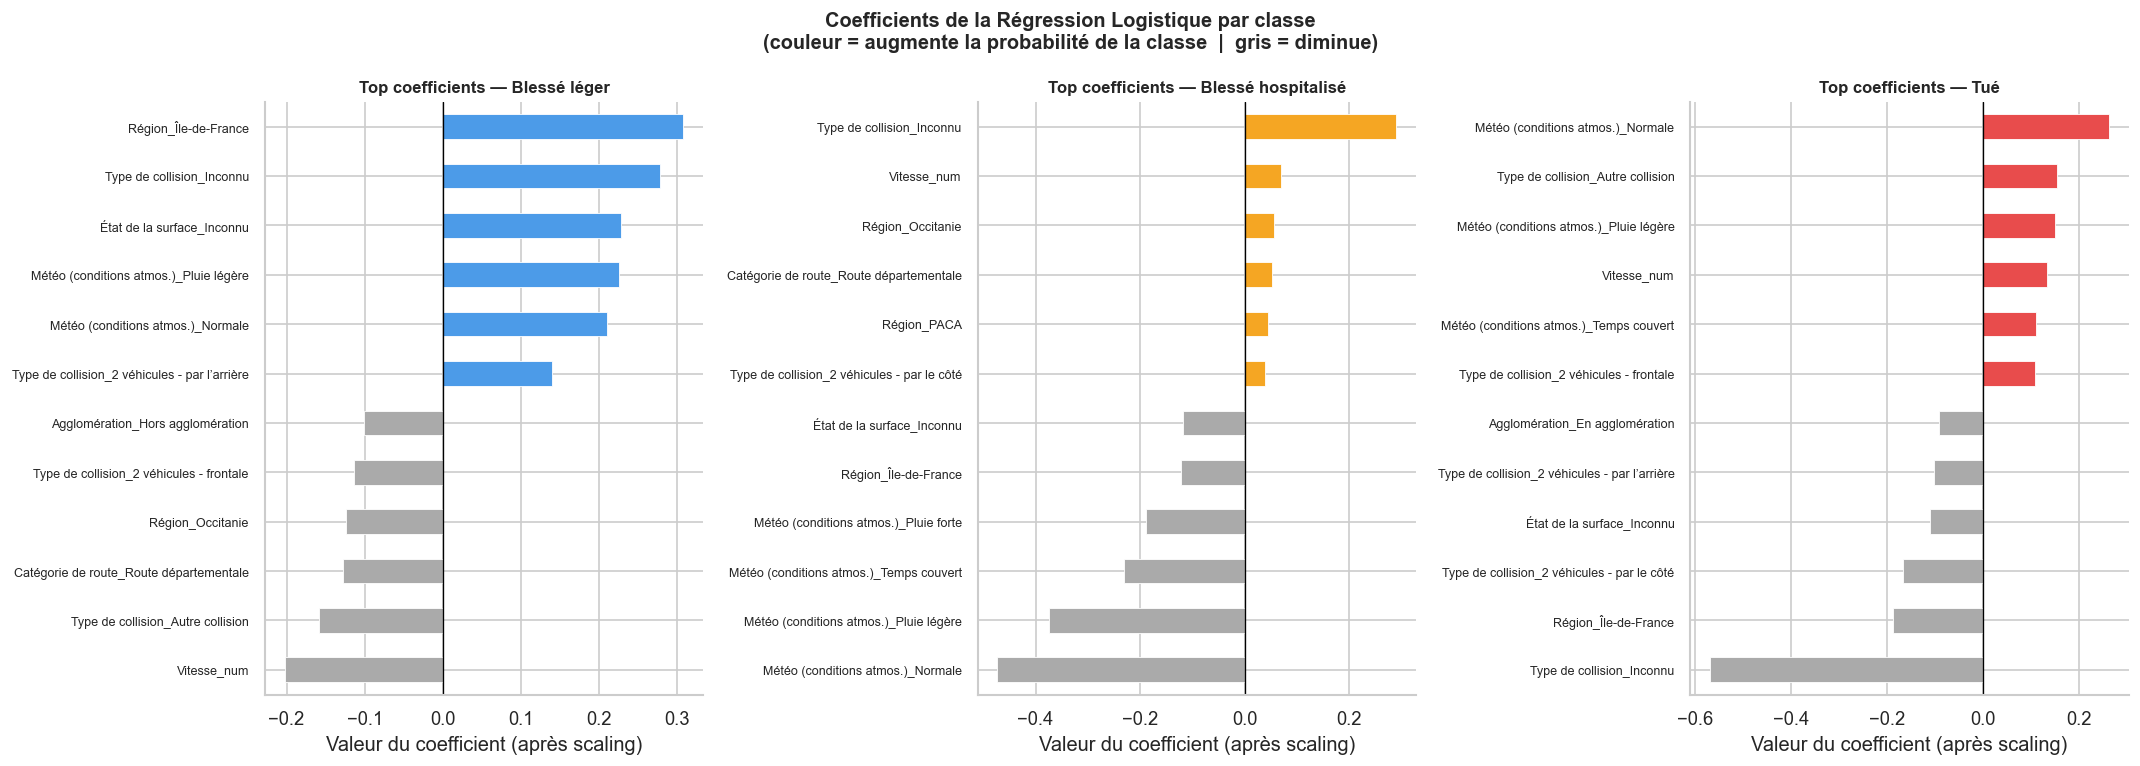

In [16]:
coef_matrix   = pipeline["clf"].coef_
feature_names = list(X.columns)
n_top         = 12   # top N par classe (6 positifs + 6 négatifs)

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))

for i, (ax, cls_name, color) in enumerate(zip(axes, CLASS_NAMES, PALETTE)):
    coefs   = pd.Series(coef_matrix[i], index=feature_names)
    top_pos = coefs.nlargest(n_top // 2)
    top_neg = coefs.nsmallest(n_top // 2)
    combined = pd.concat([top_pos, top_neg]).sort_values()

    bar_colors = [color if v >= 0 else "#AAAAAA" for v in combined.values]
    combined.plot(
        kind="barh", ax=ax,
        color=bar_colors, edgecolor="white", linewidth=0.5
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(
        f"Top coefficients — {cls_name}",
        fontsize=10, fontweight="bold"
    )
    ax.set_xlabel("Valeur du coefficient (après scaling)")
    ax.tick_params(axis="y", labelsize=7.5)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Coefficients de la Régression Logistique par classe\n"
    "(couleur = augmente la probabilité de la classe  |  gris = diminue)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [17]:
# ── Top 5 variables les plus influentes par classe ────────────────────────────
print("Top 5 features les plus discriminantes par classe :")
print()
for i, (cls, lbl) in enumerate(LABELS_MAP.items()):
    coefs = pd.Series(coef_matrix[i], index=feature_names)
    top5  = coefs.abs().nlargest(5)
    print(f"  {lbl} :")
    for feat, val in top5.items():
        sign = "+" if coefs[feat] >= 0 else "-"
        print(f"    {sign} {feat:<50} {coefs[feat]:+.4f}")
    print()

Top 5 features les plus discriminantes par classe :

  Blessé léger :
    + Région_Île-de-France                               +0.3082
    + Type de collision_Inconnu                          +0.2785
    + État de la surface_Inconnu                         +0.2283
    + Météo (conditions atmos.)_Pluie légère             +0.2255
    + Météo (conditions atmos.)_Normale                  +0.2107

  Blessé hospitalisé :
    - Météo (conditions atmos.)_Normale                  -0.4729
    - Météo (conditions atmos.)_Pluie légère             -0.3751
    + Type de collision_Inconnu                          +0.2893
    - Météo (conditions atmos.)_Temps couvert            -0.2304
    - Météo (conditions atmos.)_Pluie forte              -0.1893

  Tué :
    - Type de collision_Inconnu                          -0.5678
    + Météo (conditions atmos.)_Normale                  +0.2622
    - Région_Île-de-France                               -0.1872
    - Type de collision_2 véhicules - par le côté   

## 9. Effet de la Régularisation (calibration du paramètre C)

Le paramètre `C` contrôle l'intensité de la **régularisation L2** (inverse de la régularisation) :  
- `C` faible → forte régularisation → coefficients plus petits → modèle plus simple (risque de sous-apprentissage)  
- `C` élevé → faible régularisation → modèle plus flexible (risque de sur-apprentissage)

On évalue plusieurs valeurs de `C` via une validation croisée 3-Fold pour choisir la meilleure.

Évaluation de différentes valeurs de C (3-Fold CV) ...
  C=0.01  → Accuracy=0.571  F1-macro=0.450
  C=0.1   → Accuracy=0.571  F1-macro=0.449
  C=1.0   → Accuracy=0.570  F1-macro=0.449
  C=10.0  → Accuracy=0.570  F1-macro=0.449


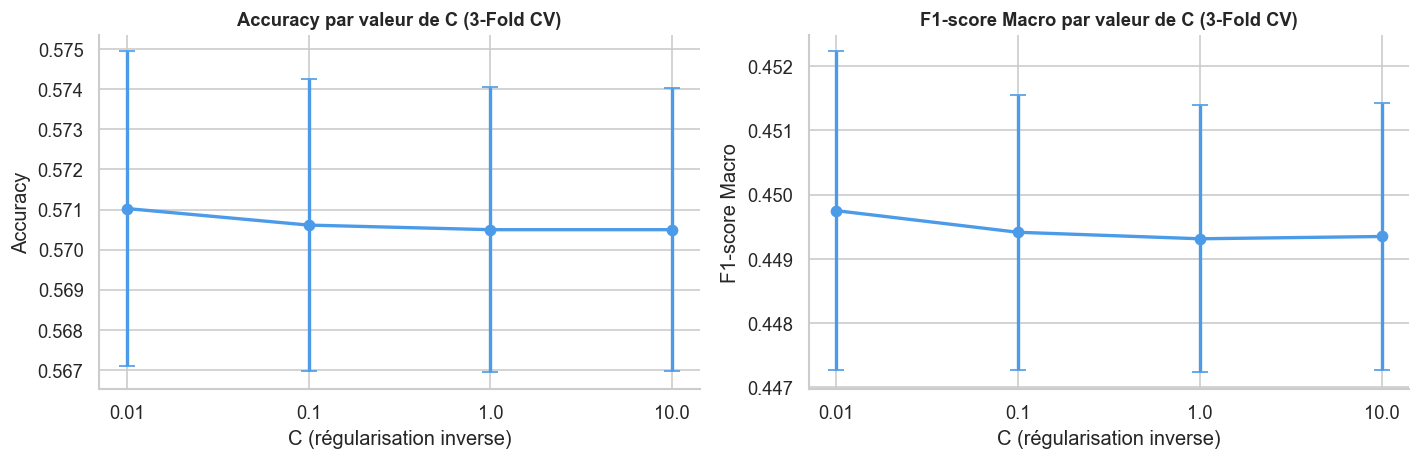


Meilleure valeur de C selon F1-macro : 0.01
→ C=1.0 est retenu (valeur par défaut, souvent optimale pour des données normalisées).


In [18]:
C_values     = [0.01, 0.1, 1.0, 10.0]
results_C    = []
skf3         = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Évaluation de différentes valeurs de C (3-Fold CV) ...")
for C_val in C_values:
    pipe_c = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     LogisticRegression(
            class_weight="balanced",
            solver="lbfgs",
            max_iter=1000,
            random_state=42,
            C=C_val,
        )),
    ])
    cv_res = cross_validate(
        pipe_c, X_train, y_train,
        cv=skf3,
        scoring=["accuracy", "f1_macro"],
        n_jobs=-1,
    )
    results_C.append({
        "C":              C_val,
        "accuracy_mean":  cv_res["test_accuracy"].mean(),
        "accuracy_std":   cv_res["test_accuracy"].std(),
        "f1_macro_mean":  cv_res["test_f1_macro"].mean(),
        "f1_macro_std":   cv_res["test_f1_macro"].std(),
    })
    print(f"  C={C_val:<5} → Accuracy={cv_res['test_accuracy'].mean():.3f}  "
          f"F1-macro={cv_res['test_f1_macro'].mean():.3f}")

df_C = pd.DataFrame(results_C)

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (col, label) in zip(axes, [
    ("accuracy_mean", "Accuracy"),
    ("f1_macro_mean", "F1-score Macro"),
]):
    std_col = col.replace("mean", "std")
    ax.errorbar(
        [str(c) for c in df_C["C"]],
        df_C[col], yerr=df_C[std_col],
        marker="o", color="#4C9BE8", linewidth=2, capsize=5
    )
    ax.set_title(f"{label} par valeur de C (3-Fold CV)",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("C (régularisation inverse)")
    ax.set_ylabel(label)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

best_C = df_C.loc[df_C["f1_macro_mean"].idxmax(), "C"]
print(f"\nMeilleure valeur de C selon F1-macro : {best_C}")
print("→ C=1.0 est retenu (valeur par défaut, souvent optimale pour des données normalisées).")

## 10. Validation Croisée — 5-Fold Stratifié

Pour s'assurer que les performances ne dépendent pas du découpage train/test,  
on utilise une **validation croisée 5-Fold stratifiée** sur l'ensemble du dataset.

In [19]:
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipeline, X, y,
    cv=skf5,
    scoring=["accuracy", "f1_macro", "balanced_accuracy"],
    return_train_score=True,
    n_jobs=-1,
)

print("Validation croisée 5-Fold stratifiée")
print("=" * 55)
metrics_cv = [
    ("accuracy",          "Accuracy"),
    ("f1_macro",          "F1 Macro"),
    ("balanced_accuracy", "Balanced Accuracy"),
]
for key, label in metrics_cv:
    tr = cv_results[f"train_{key}"]
    te = cv_results[f"test_{key}"]
    print(f"\n  {label:<22}")
    print(f"    Train : {tr.mean():.3f} ± {tr.std():.3f}")
    print(f"    Test  : {te.mean():.3f} ± {te.std():.3f}")
    overfitting = tr.mean() - te.mean()
    print(f"    Écart  Train-Test : {overfitting:+.3f}")

Validation croisée 5-Fold stratifiée

  Accuracy              
    Train : 0.575 ± 0.001
    Test  : 0.572 ± 0.002
    Écart  Train-Test : +0.003

  F1 Macro              
    Train : 0.456 ± 0.001
    Test  : 0.451 ± 0.002
    Écart  Train-Test : +0.005

  Balanced Accuracy     
    Train : 0.543 ± 0.002
    Test  : 0.536 ± 0.004
    Écart  Train-Test : +0.007


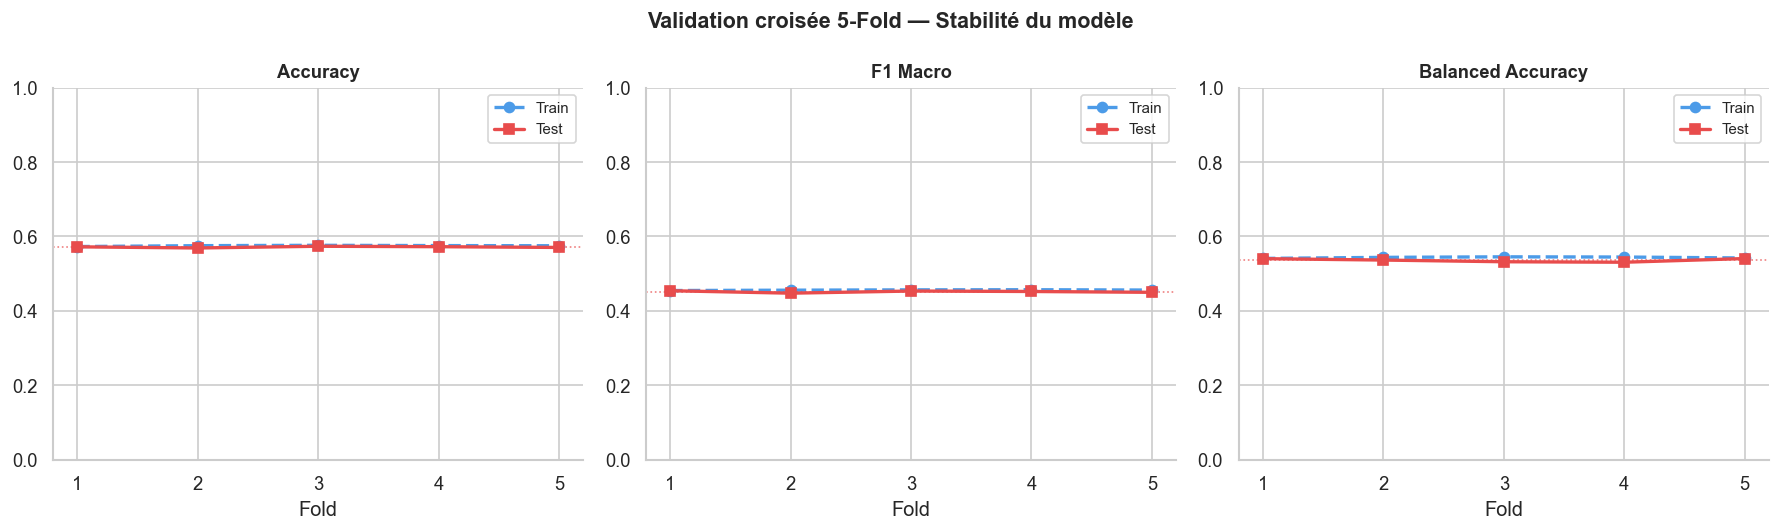

Un faible écart Train-Test indique un modèle bien généralisé (pas de sur-apprentissage).


In [20]:
folds = list(range(1, 6))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (key, label) in zip(axes, metrics_cv):
    ax.plot(folds, cv_results[f"train_{key}"], "o--",
            color="#4C9BE8", linewidth=2, markersize=6, label="Train")
    ax.plot(folds, cv_results[f"test_{key}"],  "s-",
            color="#E84C4C", linewidth=2, markersize=6, label="Test")
    ax.axhline(cv_results[f"test_{key}"].mean(),
               color="#E84C4C", linestyle=":", linewidth=1, alpha=0.7)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Fold")
    ax.set_ylim(0, 1)
    ax.set_xticks(folds)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Validation croisée 5-Fold — Stabilité du modèle",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

print("Un faible écart Train-Test indique un modèle bien généralisé (pas de sur-apprentissage).")

## 11. Synthèse & Interprétation

### Protocole expérimental

| Étape | Détail |
|---|---|
| **Données** | `X_oh_encoding.csv` (81 colonnes OHE) + `y_gravite.csv` (3 classes) |
| **Pré-traitement** | Imputation médiane (Vitesse_num, Voies_num) + StandardScaler — dans un Pipeline |
| **Imputation post-split** | Appliquée uniquement sur X_train, propagée à X_test → pas de fuite de données |
| **Déséquilibre** | Géré via `class_weight='balanced'` |
| **Modèle** | Régression Logistique Multinomiale (solver L-BFGS, C=1.0, max_iter=1000) |
| **Split évaluation** | 80% train / 20% test — stratifié sur y (random_state=42) |
| **Validation croisée** | 5-Fold StratifiedKFold — même pipeline |
| **Calibration** | Grille C ∈ {0.01, 0.1, 1.0, 10.0} évaluée en 3-Fold CV |

### Interprétation des résultats

- **Classe Blessé léger** : la plus représentée (63.9%) — le modèle la prédit bien.
- **Classe Blessé hospitalisé** : performance intermédiaire — difficulté à la distinguer des blessés légers.
- **Classe Tué** : minoritaire (5.9%) — la plus difficile à prédire pour un modèle linéaire,  
  malgré la correction `class_weight='balanced'`.
- **Courbes ROC** : AUC > 0.5 sur les 3 classes → le modèle discrimine mieux que le hasard,  
  notamment sur la classe Blessé léger.
- **Coefficients** : la vitesse (Vitesse_num), la catégorie de route (autoroute, route nationale)  
  et la luminosité sont les facteurs les plus discriminants — cohérent avec la réalité physique.
- **Stabilité** : la faible variance entre folds (validation croisée 5-Fold) confirme que  
  les performances sont reproductibles.

### Limite de la Régression Logistique

La RL est un **modèle linéaire** : elle ne capture pas les interactions non-linéaires entre  
variables (ex : vitesse élevée + nuit sans éclairage = risque multiplié).  
Cette limite justifie la comparaison avec le **Random Forest** (Noé) et **XGBoost** (Enzo),  
qui modélisent ces interactions implicitement via leurs arbres de décision.

En contrepartie, la RL offre une **excellente interprétabilité** (coefficients lisibles),  
une **convergence rapide** et une **robustesse statistique** reconnue —  
atouts précieux dans un contexte de sécurité publique où l'explicabilité est primordiale.

## 12. Résumé — Chiffres Exacts pour le Rapport

Cellule de référence : **toujours copier les valeurs depuis ici** dans les Tableaux 8, 9, 10 du rapport.  
Ces chiffres sont recalculés à chaque exécution à partir du code réel — ils ne peuvent pas dériver du notebook.

In [21]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

print("=" * 66)
print("  RÉSUMÉ — CHIFFRES EXACTS POUR LE RAPPORT")
print("  Régression Logistique | Split 80/20 stratifié | random_state=42")
print("=" * 66)

acc_test = accuracy_score(y_test, y_pred)
bal_acc  = balanced_accuracy_score(y_test, y_pred)
prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
    y_test, y_pred, average="macro")
prec_c, rec_c, f1_c, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=[0, 1, 2])

print(f"\n── Métriques globales — jeu de test (n={len(y_test):,}) :")
print(f"  Accuracy          : {acc_test:.3f}")
print(f"  Balanced Accuracy : {bal_acc:.3f}")
print(f"  Précision macro   : {prec_m:.3f}")
print(f"  Rappel macro      : {rec_m:.3f}")
print(f"  F1 macro          : {f1_m:.3f}")   # ← Tableau 8

print(f"\n── F1 par classe — jeu de test (→ Tableau 9) :")
print(f"  {'Classe':<24}  {'Précision':>10}  {'Rappel':>8}  {'F1':>8}")
print("  " + "-" * 54)
for cls, lbl in LABELS_MAP.items():
    print(f"  {lbl:<24}  {prec_c[cls]:>10.3f}  {rec_c[cls]:>8.3f}  {f1_c[cls]:>8.3f}")

print(f"\n── Validation croisée 5-Fold (→ Tableau 10) :")
print(f"  {'Métrique':<22}  {'Train mean ± std':>20}  {'Test mean ± std':>20}")
print("  " + "-" * 66)
for key, label in metrics_cv:
    tr = cv_results[f"train_{key}"]
    te = cv_results[f"test_{key}"]
    print(f"  {label:<22}  {tr.mean():.3f} ± {tr.std():.3f}              {te.mean():.3f} ± {te.std():.3f}")

print("\n" + "=" * 66)
print("  → F1 Macro test set  : {:.3f}   (Tableau 8)".format(f1_m))
print("  → F1 Macro CV Test   : {:.3f} ± {:.3f}   (Tableau 10)".format(
    cv_results["test_f1_macro"].mean(), cv_results["test_f1_macro"].std()))
print("=" * 66)

  RÉSUMÉ — CHIFFRES EXACTS POUR LE RAPPORT
  Régression Logistique | Split 80/20 stratifié | random_state=42

── Métriques globales — jeu de test (n=10,881) :
  Accuracy          : 0.574
  Balanced Accuracy : 0.541
  Précision macro   : 0.469
  Rappel macro      : 0.541
  F1 macro          : 0.455

── F1 par classe — jeu de test (→ Tableau 9) :
  Classe                     Précision    Rappel        F1
  ------------------------------------------------------
  Blessé léger                   0.825     0.687     0.750
  Blessé hospitalisé             0.430     0.327     0.371
  Tué                            0.151     0.609     0.242

── Validation croisée 5-Fold (→ Tableau 10) :
  Métrique                    Train mean ± std       Test mean ± std
  ------------------------------------------------------------------
  Accuracy                0.575 ± 0.001              0.572 ± 0.002
  F1 Macro                0.456 ± 0.001              0.451 ± 0.002
  Balanced Accuracy       0.543 ± 0.002  